# From Startup to Unicorn: Econometric Analysis of Valuation Drivers

Unicorn startups - privately held companies valued at over $1 billion - have become a key feature of the global innovation ecosystem. Although many startups are created each year, only a small share reach such high valuations. Understanding the factors that drive this success is therefore an important economic and business question.

This project aims to provide data-driven insights into the determinants of unicorn valuation using econometric methods. By analyzing a comprehensive dataset of unicorn companies, we seek to identify how financial, structural, and geographic factors are associated with higher firm valuations.

**Aim:** The main goal of this research is to identify and quantify the key drivers associated with valuation differences among unicorn companies using econometric methods. Specifically, the study examines how firm characteristics, funding patterns, industry context, and geographic factors relate to startup success at the billion-dollar level.

**Dataset:** Unicorn Companies Dataset  
**Source:** https://www.kaggle.com/datasets/deepcontractor/unicorn-companies-dataset

## 1. Environment Setup and Library Import

In this section, we import the main Python libraries required for the analysis.

- `pandas` and `numpy` are used for data manipulation and numerical operations.
- `matplotlib` and `seaborn` are used for data visualization.
- `statsmodels` is used for econometric modeling.

We also adjust a few display settings to make the output easier to read.

In [315]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

## 2. Load and Inspect the Data

At this stage, we load the dataset and perform an initial inspection of its structure.

This step is essential to understand the composition of the data, including the number of observations, variable types, and overall data quality. It also helps identify potential issues such as missing values, incorrect data formats, or variables that require transformation before analysis.

A clear understanding of the dataset at this stage ensures that subsequent data cleaning and econometric modeling are carried out correctly.

In [316]:
df = pd.read_csv("Unicorn_Companies.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1037 entries, 0 to 1036
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Sno                        1037 non-null   int64  
 1   Company                    1037 non-null   object 
 2   Valuation ($B)             1037 non-null   object 
 3   Date Joined                1037 non-null   object 
 4   Country                    1037 non-null   object 
 5   City                       1037 non-null   object 
 6   Industry                   1037 non-null   object 
 7   Inverstors                 1020 non-null   object 
 8   Founded Year               994 non-null    float64
 9   Total Raised               1013 non-null   object 
 10  Financial Stage            49 non-null     object 
 11  Investors Count            1036 non-null   float64
 12  Deal Terms                 1008 non-null   float64
 13  Portfolio Exits            49 non-null     float

In [317]:
display(df.head())

,Sno,Company,Valuation ($B),Date Joined,Country,City,Industry,Inverstors,Founded Year,Total Raised,Financial Stage,Investors Count,Deal Terms,Portfolio Exits,Unicorn Nest website link,Fund structure,Social media Presence
0,1,Bytedance,$140,4/7/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S...",2012.0,$7.44B,IPO,28.0,8.0,5.0,https://unicorn-nest.com/funds/212/,VC,Y
1,2,SpaceX,$100.30,12/1/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2002.0,$6.874B,NaN,29.0,12.0,NaN,https://unicorn-nest.com/funds/415/,VC,Y
2,3,Stripe,$95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG",2010.0,$2.901B,Asset,39.0,12.0,1.0,https://unicorn-nest.com/funds/2020/,VC,Y
3,4,Klarna,$45.60,12/12/2011,Sweden,Stockholm,Fintech,"Institutional Venture Partners, Sequoia Capita...",2005.0,$3.472B,Acquired,56.0,13.0,1.0,https://unicorn-nest.com/funds/21212/,VC,Y
4,5,Epic Games,$42,10/26/2018,United States,Cary,Other,"Tencent Holdings, KKR, Smash Ventures",1991.0,$4.377B,Acquired,25.0,5.0,2.0,https://unicorn-nest.com/funds/406-ventures/,VC,Y


In [318]:
df.describe()

,Sno,Founded Year,Investors Count,Deal Terms,Portfolio Exits
count,1037.000000,994.000000,1036.000000,1008.000000,49.000000
mean,519.000000,2012.710262,14.432432,3.093254,1.346939
std,299.500417,5.942876,9.946537,2.159764,0.751416
min,1.000000,1919.000000,1.000000,1.000000,1.000000
25%,260.000000,2011.000000,8.000000,1.000000,1.000000
50%,519.000000,2014.000000,13.000000,3.000000,1.000000
75%,778.000000,2016.000000,19.000000,4.000000,1.000000
max,1037.000000,2021.000000,91.000000,19.000000,5.000000


### Data Structure

The dataset used in this analysis is **cross-sectional**, meaning it captures a snapshot of unicorn companies at a specific point in time rather than tracking their evolution over time. Each observation represents a single firm that has reached a valuation of at least $1 billion.

The dataset consists of **1,037 observations** and **17 variables**, covering financial, temporal, geographic, and investor-related characteristics of unicorn companies. 

The variables are of mixed data types:

- **Numeric variables (float/int):**
  - Founded Year
  - Investors Count
  - Deal Terms
  - Portfolio Exits

- **Categorical/text variables:**
  - Company, Country, City, Industry
  - Financial Stage, Fund structure, Social media Presence
  - Valuation, Total Raised

A key observation is that **most important financial variables are stored as strings**, meaning they must be cleaned before analysis.

### Missing Values Overview

The dataset shows uneven data completeness across variables:

- Almost complete:
  - Company, Country, City, Industry, Valuation, Date Joined

- Moderately missing:
  - Total Raised (1013 non-null)
  - Fund structure (979 non-null)
  - Social media Presence (981 non-null)

- Heavily missing:
  - Financial Stage (49 non-null)
  - Portfolio Exits (49 non-null)

This suggests that these variables require careful treatment before inclusion in the analysis. Ignoring missing values could bias the results and reduce the reliability of the econometric estimates.

### Descriptive Statistics Overview

The summary statistics provide several initial insights:

- The **average founding year (~2013)** suggests that unicorns are typically young firms.  
- The **number of investors varies widely** (from 1 to 91).  
- The **median number of deal terms is 3**, with some firms reaching up to 19 rounds.

## 3. Data Cleaning & Preprocessing

Before conducting econometric analysis, it is necessary to transform raw variables into a usable format.

The dataset contains several variables stored as strings (e.g., monetary values), missing values, and categorical variables that require encoding.

Key preprocessing steps:
- Convert monetary variables into numeric format
- Handle missing values
- Convert date variables
- Create derived variables

In [319]:
df = df.copy()

# renaming columns
df = df.rename(columns={
    "Valuation ($B)": "valuation",
    "Date Joined": "date_joined",
    "Founded Year": "founded_year",
    "Total Raised": "total_raised",
    "Financial Stage": "financial_stage",
    "Investors Count": "investors_count",
    "Deal Terms": "deal_terms",
    "Portfolio Exits": "portfolio_exits",
    "Fund structure": "fund_structure",
    "Social media Presence": "social_media_presence",
    "Inverstors": "investors"
})

# clean money (convert to billions USD)
def money_to_billions(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip().replace("$", "").replace(",", "")
    
    if x == "" or x.lower() in ["unknown", "undisclosed", "n/a", "nan"]:
        return np.nan
    
    multiplier = 1.0
    if x.endswith("B"):
        multiplier = 1
        x = x[:-1]
    elif x.endswith("M"):
        multiplier = 1 / 1000
        x = x[:-1]
    elif x.endswith("K"):
        multiplier = 1 / 1_000_000
        x = x[:-1]
    
    try:
        return float(x) * multiplier
    except:
        return np.nan

df["valuation"] = df["valuation"].apply(money_to_billions)
df["total_raised"] = df["total_raised"].apply(money_to_billions)

# convert dates
df["date_joined"] = pd.to_datetime(df["date_joined"], errors="coerce")
df["joined_year"] = df["date_joined"].dt.year

# numeric conversion
numeric_cols = [
    "founded_year",
    "investors_count",
    "deal_terms",
    "portfolio_exits"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# founded year and joined year as nullable integer
df["founded_year"] = df["founded_year"].astype("Int64")
df["joined_year"] = df["joined_year"].astype("Int64")

# create derived variables
df["age_to_unicorn"] = df["joined_year"] - df["founded_year"]
df.loc[df["age_to_unicorn"] < 0, "age_to_unicorn"] = np.nan

df["is_us"] = (df["Country"] == "United States").astype(int)
df["is_china"] = (df["Country"] == "China").astype(int)

# overwriting social media presence with 1s and 0s
df["social_media_presence"] = df["social_media_presence"].map({"Y": 1, "N": 0})

In [320]:
# drop variables with extreme missingness to avoid loss of observations
df = df.drop(columns=["financial_stage", "portfolio_exits"])

# median imputation for numeric variables
df["founded_year"] = df["founded_year"].fillna(df["founded_year"].median())
df["investors_count"] = df["investors_count"].fillna(df["investors_count"].median())
df["total_raised"] = df["total_raised"].fillna(df["total_raised"].median())
df["deal_terms"] = df["deal_terms"].fillna(df["deal_terms"].median())

# cold imputation
df['investors'] = df.groupby('Industry')['investors'].transform(lambda x: x.ffill().bfill())

# mode imputation for categorical variables
df["fund_structure"] = df["fund_structure"].fillna(df["fund_structure"].mode()[0])
df["social_media_presence"] = df["social_media_presence"].fillna(df["social_media_presence"].mode()[0])

/var/folders/9t/smzhpxbj147fk1w2htxb4mnr0000gn/T/ipykernel_95708/386680875.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['investors'] = df.groupby('Industry')['investors'].transform(lambda x: x.ffill().bfill())


In [321]:
display(df.head())

,Sno,Company,valuation,date_joined,Country,City,Industry,investors,founded_year,total_raised,investors_count,deal_terms,Unicorn Nest website link,fund_structure,social_media_presence,joined_year,age_to_unicorn,is_us,is_china
0,1,Bytedance,140.0,2017-04-07,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S...",2012,7.440,28.0,8.0,https://unicorn-nest.com/funds/212/,VC,1.0,2017,5,0,1
1,2,SpaceX,100.3,2012-12-01,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen...",2002,6.874,29.0,12.0,https://unicorn-nest.com/funds/415/,VC,1.0,2012,10,1,0
2,3,Stripe,95.0,2014-01-23,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG",2010,2.901,39.0,12.0,https://unicorn-nest.com/funds/2020/,VC,1.0,2014,4,1,0
3,4,Klarna,45.6,2011-12-12,Sweden,Stockholm,Fintech,"Institutional Venture Partners, Sequoia Capita...",2005,3.472,56.0,13.0,https://unicorn-nest.com/funds/21212/,VC,1.0,2011,6,0,0
4,5,Epic Games,42.0,2018-10-26,United States,Cary,Other,"Tencent Holdings, KKR, Smash Ventures",1991,4.377,25.0,5.0,https://unicorn-nest.com/funds/406-ventures/,VC,1.0,2018,27,1,0


### Column Renaming

Several columns were renamed to improve readability and ensure consistency in naming conventions.

### Monetary Variable Transformation

The variables **valuation** and **total_raised** were originally stored as strings containing symbols (e.g., `$`, `B`, `M`).  

To make them usable for analysis, they were converted into numeric format using a custom function:

- All values were standardized into **billions of USD**
- Symbols and formatting inconsistencies were removed
- Non-valid entries were converted to missing values

### Date Conversion

The variable **date_joined** was converted into a proper datetime format. From this, a new variable was extracted:

- **joined_year** - the year in which the company became a unicorn

### Derived Variable Construction

A key variable introduced in the analysis is: $\text{age\_to\_unicorn} = \text{joined\_year} - \text{founded\_year}$

This measures how quickly a company reached unicorn status and serves as an important indicator of growth speed.

### Categorical Variable Encoding

The variable **social_media_presence** was transformed into a binary indicator:

- 1 = presence  
- 0 = absence  

### Handling Missing Values

The dataset contained missing values across several variables. Different strategies were applied depending on the variable type and importance.

1. Variables with extreme missingness were removed:

    - financial_stage  
    - portfolio_exits  

2.  Median Imputation (Numeric Variables)

    - founded_year  
    - investors_count  
    - total_raised  
    - deal_terms  

3.  Mode Imputation (Categorical Variables)

    - fund_structure  
    - social_media_presence  

4.  Group-Based Imputation
For the **investors** variable, missing values were filled using forward and backward filling within each industry group.

## 4. Exploratory Data Analysis

Before estimating the econometric models, we conducted an exploratory data analysis to examine the distributions, relationships, and potential issues within the dataset.

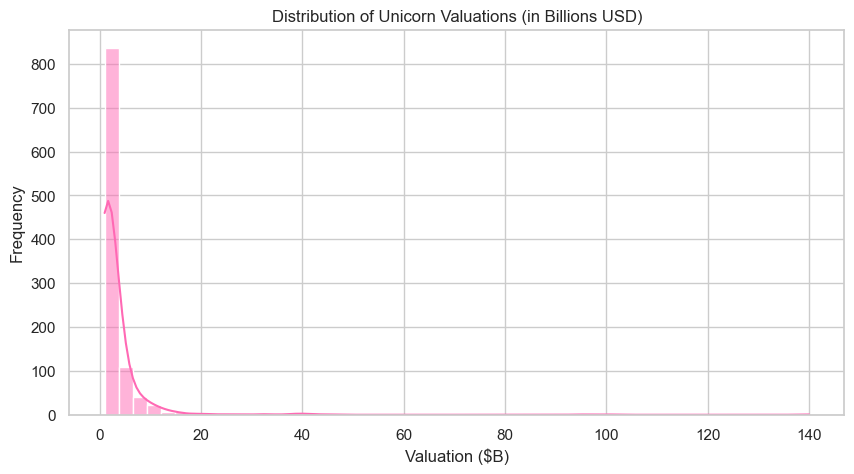

In [322]:
plt.figure(figsize=(10, 5))
sns.histplot(df["valuation"], bins=50, kde=True, color="hotpink")
plt.title("Distribution of Unicorn Valuations (in Billions USD)")
plt.xlabel("Valuation ($B)")
plt.ylabel("Frequency")
plt.show()

The histogram of company valuations reveals a heavily right-skewed distribution. The vast majority of unicorns cluster near the $1 billion to $3 billion threshold. However, there is a long right tail driven by a few "decacorns" and "hectocorns" (e.g., Bytedance and SpaceX) with valuations exceeding $100 billion. 

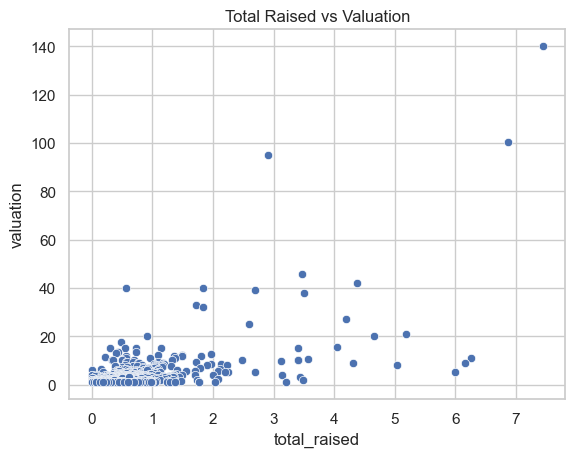

In [323]:
sns.scatterplot(x="total_raised", y="valuation", data=df)
plt.title("Total Raised vs Valuation")
plt.show()

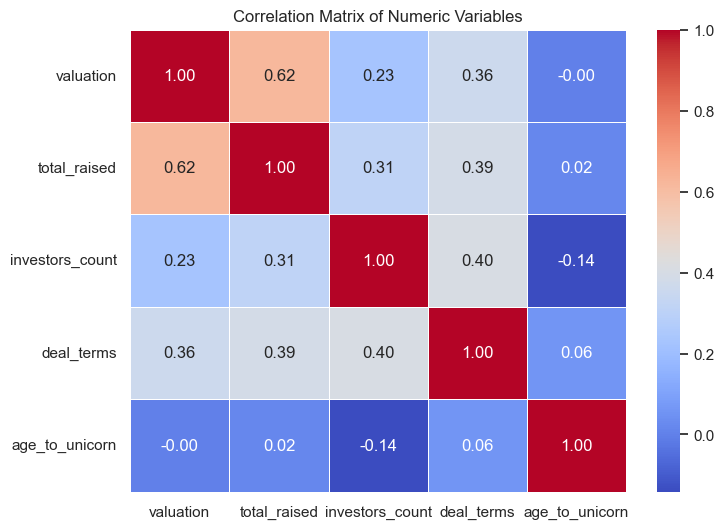

In [324]:
corr_cols = ["valuation", "total_raised", "investors_count", "deal_terms", "age_to_unicorn"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

To test for potential multicollinearity among our explanatory variables, we generated a Pearson correlation matrix. 
* **Valuation and Total Raised:** There is a strong positive correlation between the total capital raised and the final valuation, which aligns with economic intuition.
* **Multicollinearity Check:** None of the independent variables (e.g., `investors_count`, `deal_terms`, `age_to_unicorn`) exhibit correlations high enough ($> 0.8$) to cause severe multicollinearity issues.

/var/folders/9t/smzhpxbj147fk1w2htxb4mnr0000gn/T/ipykernel_95708/1793392278.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='joined_year', palette='magma')


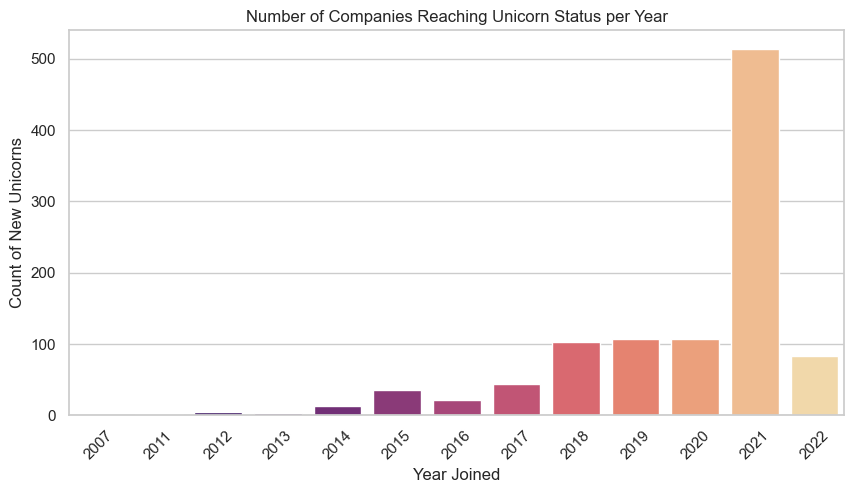

In [325]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='joined_year', palette='magma')
plt.title("Number of Companies Reaching Unicorn Status per Year")
plt.xlabel("Year Joined")
plt.ylabel("Count of New Unicorns")
plt.xticks(rotation=45)
plt.show()

Although this is a cross-sectional dataset, analyzing the `joined_year` provides essential macroeconomic context. The bar chart demonstrates a dramatic exponential increase in the number of startups achieving unicorn status, peaking significantly around 2021. 

This "unicorn boom" likely reflects broader macroeconomic conditions during that period, such as low-interest-rate environments and an influx of venture capital liquidity, rather than just a sudden increase in startup quality.

## 5. Hypotheses and objectives description

### Variables Introduction

To test our hypotheses, we examine the relationships between our dependent variable and several independent variables:

* **Dependent Variable ($y$):** $\ln(\text{Valuation})$. We use a log transformation to account for the highly right-skewed nature of startup valuations.

* **Independent Variables ($x$):** 
Total funding raised, the company's age at the time of becoming a unicorn ($\text{Date Joined} - \text{Year Founded}$), dummy variables for specific industries and locations, and the total number of backing investors.


### Statistical Meaning and Formulation of Hypotheses

#### Task 1: Capital accumulation and valuation

* **Variable:** $x_1 = \text{Total Raised}$, coefficient $\beta_1$

* **Hypothesis:** Companies that raise more funding tend to have higher valuations.

$$
\begin{aligned}
H_0 &: \beta_1 \leq 0 \\
H_1 &: \beta_1 > 0
\end{aligned}
$$


#### Task 2: Company age and valuation

* **Variable:** $x_2 = \text{Age}$, coefficient $\beta_2$

* **Question:** Does the age of a company at the time of becoming a unicorn affect its valuation?

$$
\begin{aligned}
H_0 &: \beta_2 = 0 \\
H_1 &: \beta_2 \neq 0
\end{aligned}
$$



#### Task 3: Industry and location effects

* **Variables:** 
    * Industry dummy (e.g., $D_{\text{fintech}}$), coefficient $\gamma$
    * Location dummy (e.g., $D_{\text{US}}$), coefficient $\delta$

* **Hypothesis:** Startups in tech sectors and innovation hubs tend to have higher valuations.

**Industry:**

$$
\begin{aligned}
H_0 &: \gamma_{\text{fintech}} \leq 0 \\
H_1 &: \gamma_{\text{fintech}} > 0
\end{aligned}
$$

**Location:**

$$
\begin{aligned}
H_0 &: \delta_{\text{US}} \leq 0 \\
H_1 &: \delta_{\text{US}} > 0
\end{aligned}
$$


#### Task 4: Investor backing and valuation

* **Variable:** $x_4 = \text{Number of Investors}$, coefficient $\beta_4$

* **Question:** Do companies with more investors achieve higher valuations?

$$
\begin{aligned}
H_0 &: \beta_4 \leq 0 \\
H_1 &: \beta_4 > 0
\end{aligned}
$$



#### Task 5: Interaction effect (U.S.)

* **Variable:** $\log(\text{Total Raised}) \cdot D_{\text{US}}$, coefficient $\beta_5$

* **Hypothesis:** The effect of funding on valuation is stronger for U.S.-based startups.

$$
\begin{aligned}
H_0 &: \beta_5 \leq 0 \\
H_1 &: \beta_5 > 0
\end{aligned}
$$



## 5. Description of Methods

#### **Descriptive Statistics**

Descriptive statistics are used to summarize the main characteristics of the dataset before estimation. These include measures of central tendency (mean, median) and dispersion (standard deviation).

This step helps identify key features of the data, such as skewness, variability, and the presence of outliers, which informs model specification decisions.

#### **Ordinary Least Squares (OLS) Regression**

The main method will be Ordinary Least Squares (OLS) regression, which will be used to
estimate the relationship between unicorn valuation and a set of explanatory variables, including
total funds raised, time to reach unicorn status, number of investors, industry classification, and
geographic location. OLS is appropriate because the dependent variable, Valuation, is continuous.

#### **Logarithmic Transformation**

Due to the presence of strong right-skewness in the distribution of valuation, a logarithmic transformation of the dependent variable is applied.

The transformed model takes the form:
$$
\log(\mathrm{Y}_i) = X_i \beta + u_i
$$

This transformation reduces the influence of extreme values, improves the distribution of residuals, stabilizes variance, allows coefficients to be interpreted approximately as percentage changes.

#### **Dummy Variables**

Categorical variables such as industry and country cannot be directly included in an OLS regression, as the model requires numerical inputs. Therefore, these variables are transformed into dummy variables.

For a categorical variable with $K$ categories, $K - 1$ dummy variables are created:

$$
D_{ik} =
\begin{cases}
1, & \text{if observation } i \text{ belongs to category } k \\
0, & \text{otherwise}
\end{cases}
$$

One category is omitted as a base group to avoid perfect multicollinearity. The coefficients on dummy variables represent differences in valuation relative to this baseline.

In this study, dummy variables are used to capture industry and country effects. In this specification, the baseline category for industry is "Other", which represents a broad and relatively neutral group, while the baseline category for country is the United States, as it represents the leading market for unicorn companies and provides a meaningful benchmark for comparison.

#### **Model Specification**

The empirical analysis is based on a log-linear regression model that relates unicorn company valuation to financial, structural, and geographic characteristics.

The estimated model is specified as follows:

$$
\log(\mathrm{Valuation}_i) =
\beta_0 +
\beta_1 \mathrm{TotalRaised}_i +
\beta_2 \mathrm{InvestorsCount}_i +
\beta_3 \mathrm{Age}_i +
\sum_{k} \gamma_k D_{ik} +
u_i
$$

where $i$ indexes individual companies.

The dependent variable is the natural logarithm of company valuation. This transformation is applied to address the strong right-skewness of the valuation distribution and to allow interpretation of coefficients in percentage terms.

The explanatory variables include:

- $\mathrm{TotalRaised}_i$ — the total amount of funding raised by company $i$, measured in billions of USD. This variable captures the effect of capital accumulation on firm valuation;

- $\mathrm{InvestorsCount}_i$ — the number of investors backing company $i$, reflecting the breadth of investor support and potential signaling effects;

- $\mathrm{Age}_i$ — the time (in years) between the founding of the company and the date it achieved unicorn status, capturing differences in growth dynamics across firms;

- $D_{ik}$ — a set of dummy variables representing categorical characteristics such as industry and country. These variables allow the model to account for sector-specific and geographic differences in valuation. Therefore, the coefficients $\gamma_k$ measure differences in valuation relative to these reference groups.

The term $u_i$ denotes the error term, which captures all unobserved factors affecting valuation that are not included in the model.

### Hypothesis Testing

### **1. T-test for Individual Parameter Significance**
To test whether individual variables have a statistically significant relationship with valuation, we use the student's t-test.

**Test Statistic Formula:**
$$t = \frac{\hat{\beta}_j - \beta_{j,0}}{SE(\hat{\beta}_j)}$$

Where $\hat{\beta}_j$ is the estimated coefficient, $\beta_{j,0}$ is the hypothesized value (which is $0$ under the null hypothesis), and $SE(\hat{\beta}_j)$ is the standard error of the estimated coefficient.

We will reject the null hypothesis $H_0$ if the calculated t-statistic falls in the rejection region (based on our chosen significance level $\alpha = 0.05$) or if the p-value is less than $\alpha$.

#### **2. F-test for Overall Model Significance**

To test whether the explanatory variables are jointly significant in explaining company valuation, we use the F-test.

**Test Statistic Formula:**

$$
F = \frac{(SSR_{restricted} - SSR_{unrestricted}) / q}{SSR_{unrestricted} / (n - k)}
$$

where $SSR_{restricted}$ and $SSR_{unrestricted}$ are the sums of squared residuals for the restricted and full models, respectively, $q$ is the number of restrictions, $n$ is the sample size, and $k$ is the number of estimated parameters.

The null hypothesis is:

$$
H_0: \beta_1 = \beta_2 = \dots = \beta_k = 0
$$

We reject $H_0$ if the F-statistic exceeds the critical value or if the p-value is less than $\alpha = 0.05$.

#### **Multicollinearity (Variance Inflation Factor, VIF)**

To assess the presence of multicollinearity among explanatory variables, the Variance Inflation Factor (VIF) is used.

**Formula:**

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

where $R_j^2$ is the coefficient of determination obtained from regressing explanatory variable $j$ on all other explanatory variables.

Multicollinearity occurs when explanatory variables are highly correlated with each other. This does not bias the OLS estimates, but it increases the variance of the estimated coefficients, making them less precise and statistically less reliable.

VIF value greater than 10 indicates a potentially serious multicollinearity problem.

In this study, VIF is used to ensure that the included regressors provide independent information and that the estimated coefficients can be interpreted reliably.

#### **Heteroskedasticity**

Heteroskedasticity refers to a violation of the classical OLS assumption that the variance of the error term $u_i$ is constant across observations.

Formally, the assumption is:

$$
\mathrm{Var}(u_i \mid X_i) = \sigma^2
$$

When this condition does not hold, the variance of the error term varies with the level of explanatory variables.

Although OLS estimates remain unbiased and consistent under heteroskedasticity, the standard errors become biased, which leads to unreliable hypothesis testing.

To address this issue, heteroskedasticity-robust standard errors are applied, ensuring valid statistical inference even when the variance of the error term is not constant.